# Behavioral Customer Segmentation


## 1. Imports

In [1]:
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## 2. Configuration


In [3]:
RAW_DATA_PATH = r"C:\online_retail_II.csv"

MODELS_DIR = Path("models")
REPORTS_DIR = Path("reports")
FIGURES_DIR = REPORTS_DIR / "figures"
for d in (MODELS_DIR, REPORTS_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

REQUIRED_COLUMNS = ["Invoice", "StockCode", "Description", "Quantity", "InvoiceDate", "Price", "Customer ID", "Country"]

COLUMN_ALIASES = {
    "invoiceno": "Invoice", "invoice": "Invoice",
    "stockcode": "StockCode", "description": "Description",
    "quantity": "Quantity", "invoicedate": "InvoiceDate",
    "unitprice": "Price", "price": "Price",
    "customerid": "Customer ID", "customer id": "Customer ID",
    "country": "Country",
}

# Clustering hyperparameter search space (ranges to try, not final choices)
KMEANS_K_RANGE = range(2, 11)
AGG_K_RANGE = range(2, 9)
AGG_LINKAGES = ["ward", "complete", "average"]
GMM_N_RANGE = range(2, 9)
GMM_COV_TYPES = ["full", "tied", "diag"]

OUTLIER_UPPER_QUANTILE = 0.99
CLUSTERING_FEATURES = ["Recency", "Frequency", "Monetary", "AvgOrderValue",
                        "TotalQuantity", "UniqueProducts", "AvgItemsPerOrder",
                        "CustomerLifetimeDays", "PurchaseFrequencyRate"]

assert RAW_DATA_PATH, "Set RAW_DATA_PATH above before running the rest of this notebook."
RAW_DATA_PATH = Path(RAW_DATA_PATH)
print("behavioral_customer_segmentation_data_online_retail_II.csv")


behavioral_customer_segmentation_data_online_retail_II.csv


## 3. Load & Validate the Dataset


In [4]:
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    rename_map = {}
    for col in df.columns:
        key = str(col).strip().lower()
        if key in COLUMN_ALIASES:
            rename_map[col] = COLUMN_ALIASES[key]
    return df.rename(columns=rename_map)


def load_raw_dataset(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(
            f"Dataset not found at '{path}'.\n"
            "Download 'Online Retail II' from:\n"
            "  Kaggle: https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci\n"
            "  UCI:    https://archive.ics.uci.edu/dataset/502/online+retail+ii\n"
            "Then set RAW_DATA_PATH in the Configuration cell above."
        )

    if path.suffix.lower() == ".csv":
        df = pd.read_csv(path, encoding="ISO-8859-1")
        df = normalize_columns(df)
    else:
        sheets = pd.read_excel(path, sheet_name=None)
        df = pd.concat([normalize_columns(s) for s in sheets.values()], ignore_index=True)

    missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(f"Dataset is missing required column(s): {missing}. Found: {list(df.columns)}")

    print(f"Loaded {len(df):,} raw rows, {df.shape[1]} columns from {path.name}")
    return df


raw_df = load_raw_dataset(RAW_DATA_PATH)
raw_df.head()


Loaded 1,067,371 raw rows, 8 columns from online_retail_II.csv


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom


## 4. Data Cleaning


In [5]:
def clean_transactions(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    df = df.copy()
    report_rows = [{"metric": "rows_before_cleaning", "value": len(df)}]

    df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
    before = len(df); df = df[df["InvoiceDate"].notna()]
    report_rows.append({"metric": "removed_unparseable_dates", "value": before - len(df)})

    before = len(df); df = df[df["Customer ID"].notna()]
    report_rows.append({"metric": "removed_missing_customer_id", "value": before - len(df)})

    before = len(df)
    df = df[df["Description"].notna() & (df["Description"].astype(str).str.strip() != "")]
    report_rows.append({"metric": "removed_missing_description", "value": before - len(df)})

    before = len(df); df = df.drop_duplicates()
    report_rows.append({"metric": "removed_duplicate_rows", "value": before - len(df)})

    df["Invoice"] = df["Invoice"].astype(str)
    is_cancelled = df["Invoice"].str.startswith("C")
    report_rows.append({"metric": "removed_cancelled_invoices", "value": int(is_cancelled.sum())})
    df = df[~is_cancelled]

    before = len(df); df = df[df["Quantity"] > 0]
    report_rows.append({"metric": "removed_non_positive_quantity", "value": before - len(df)})

    before = len(df); df = df[df["Price"] > 0]
    report_rows.append({"metric": "removed_non_positive_price", "value": before - len(df)})

    df["Customer ID"] = df["Customer ID"].astype("Int64").astype(str)

    report_rows.append({"metric": "rows_after_cleaning", "value": len(df)})
    report_rows.append({"metric": "unique_customers", "value": df["Customer ID"].nunique()})
    report_rows.append({"metric": "unique_products", "value": df["StockCode"].nunique()})
    report_rows.append({"metric": "unique_invoices", "value": df["Invoice"].nunique()})
    report_rows.append({"metric": "date_range_start", "value": str(df["InvoiceDate"].min().date())})
    report_rows.append({"metric": "date_range_end", "value": str(df["InvoiceDate"].max().date())})

    return df.reset_index(drop=True), pd.DataFrame(report_rows)


clean_df, cleaning_report = clean_transactions(raw_df)
cleaning_report.to_csv(REPORTS_DIR / "data_quality_report.csv", index=False)
cleaning_report


,metric,value
0,rows_before_cleaning,1067371
1,removed_unparseable_dates,0
2,removed_missing_customer_id,243007
3,removed_missing_description,0
4,removed_duplicate_rows,26479
5,removed_cancelled_invoices,18390
6,removed_non_positive_quantity,0
7,removed_non_positive_price,70
8,rows_after_cleaning,779425
9,unique_customers,5878


## 5. Exploratory Data Analysis


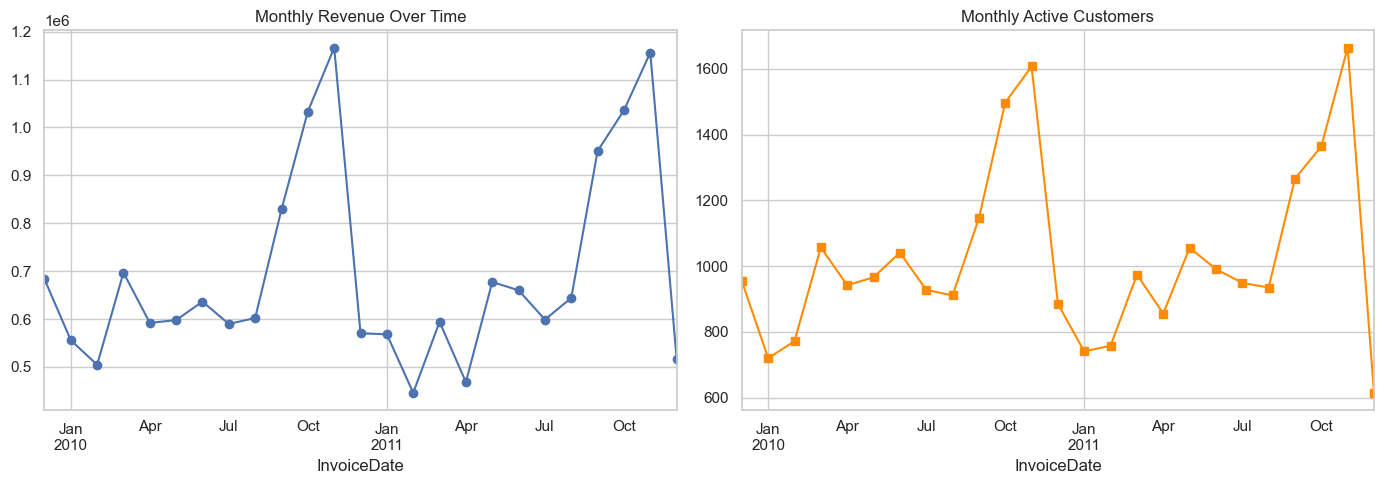

In [6]:
clean_df["LineRevenue"] = clean_df["Quantity"] * clean_df["Price"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
monthly_rev = clean_df.set_index("InvoiceDate").resample("ME")["LineRevenue"].sum()
monthly_rev.plot(ax=axes[0], marker="o")
axes[0].set_title("Monthly Revenue Over Time")

monthly_cust = clean_df.set_index("InvoiceDate").resample("ME")["Customer ID"].nunique()
monthly_cust.plot(ax=axes[1], marker="s", color="darkorange")
axes[1].set_title("Monthly Active Customers")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_revenue_and_customers_over_time.png", dpi=150)
plt.show()


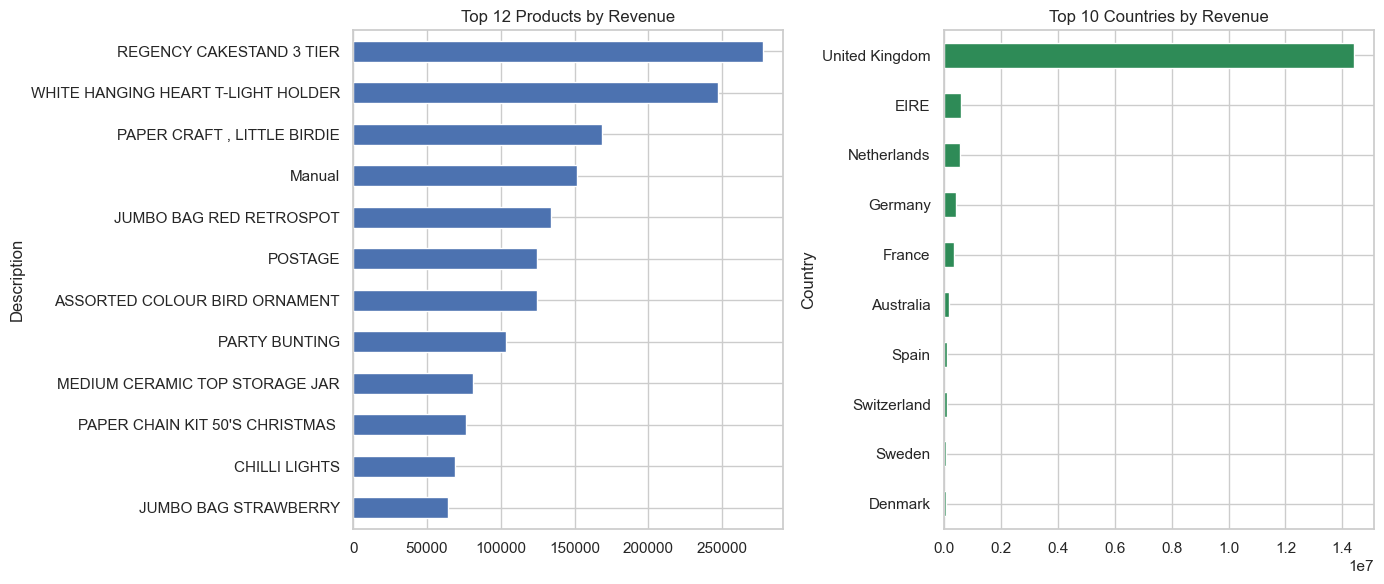

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_products = clean_df.groupby("Description")["LineRevenue"].sum().nlargest(12).sort_values()
top_products.plot(kind="barh", ax=axes[0])
axes[0].set_title("Top 12 Products by Revenue")

top_countries = clean_df.groupby("Country")["LineRevenue"].sum().nlargest(10).sort_values()
top_countries.plot(kind="barh", ax=axes[1], color="seagreen")
axes[1].set_title("Top 10 Countries by Revenue")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_top_products_and_countries.png", dpi=150)
plt.show()


## 6. RFM Analysis


In [8]:
reference_date = clean_df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(f"RFM reference date (derived from data): {reference_date.date()}")

rfm = clean_df.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda s: (reference_date - s.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("LineRevenue", "sum"),
)
rfm.describe()


RFM reference date (derived from data): 2011-12-10


,Recency,Frequency,Monetary
count,"5,878.00","5,878.00","5,878.00"
mean,201.33,6.29,"2,955.90"
std,209.34,13.01,"14,440.85"
min,1.00,1.00,2.95
25%,26.00,1.00,342.28
50%,96.00,3.00,867.74
75%,380.00,7.00,"2,248.30"
max,739.00,398.00,"580,987.04"


## 7. Additional Behavioral Feature Engineering


In [9]:
FEATURE_DICTIONARY = {
    "Recency": "Days since the customer's most recent purchase.",
    "Frequency": "Number of distinct orders placed.",
    "Monetary": "Total revenue generated.",
    "AvgOrderValue": "Monetary / Frequency.",
    "TotalQuantity": "Total items purchased across all orders.",
    "UniqueProducts": "Count of distinct products purchased.",
    "AvgItemsPerOrder": "TotalQuantity / Frequency.",
    "CustomerLifetimeDays": "Days between first and last purchase.",
    "AvgDaysBetweenPurchases": "CustomerLifetimeDays / (Frequency-1); NaN for single-order customers.",
    "PurchaseFrequencyRate": "Frequency / (CustomerLifetimeDays + 1).",
    "ProductDiversityRatio": "UniqueProducts / TotalQuantity.",
    "PrimaryCountry": "Most frequent country associated with the customer.",
}

agg = clean_df.groupby("Customer ID").agg(
    TotalQuantity=("Quantity", "sum"),
    UniqueProducts=("StockCode", "nunique"),
    FirstPurchase=("InvoiceDate", "min"),
    LastPurchase=("InvoiceDate", "max"),
)

features = rfm.join(agg)
features["AvgOrderValue"] = features["Monetary"] / features["Frequency"]
features["AvgItemsPerOrder"] = features["TotalQuantity"] / features["Frequency"]
features["CustomerLifetimeDays"] = (features["LastPurchase"] - features["FirstPurchase"]).dt.days
features["AvgDaysBetweenPurchases"] = features.apply(
    lambda r: r["CustomerLifetimeDays"] / (r["Frequency"] - 1) if r["Frequency"] > 1 else np.nan, axis=1
)
features["PurchaseFrequencyRate"] = features["Frequency"] / (features["CustomerLifetimeDays"] + 1)
features["ProductDiversityRatio"] = features["UniqueProducts"] / features["TotalQuantity"]

primary_country = clean_df.groupby("Customer ID")["Country"].agg(lambda s: s.value_counts().idxmax())
features = features.join(primary_country.rename("PrimaryCountry"))
features = features.drop(columns=["FirstPurchase", "LastPurchase"])

features.to_csv(REPORTS_DIR / "customer_features.csv")
print(f"Built {features.shape[1]} features for {features.shape[0]:,} customers")
features.head()


Built 12 features for 5,878 customers


,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,AvgOrderValue,AvgItemsPerOrder,CustomerLifetimeDays,AvgDaysBetweenPurchases,PurchaseFrequencyRate,ProductDiversityRatio,PrimaryCountry
Customer ID,,,,,,,,,,,,
12346,326,12,"77,556.46",74285,27,"6,463.04","6,190.42",400,36.36,0.03,0.00,United Kingdom
12347,2,8,"4,921.53",2967,126,615.19,370.88,402,57.43,0.02,0.04,Iceland
12348,75,5,"2,019.40",2714,25,403.88,542.80,362,90.50,0.01,0.01,Finland
12349,19,4,"4,428.69",1624,138,"1,107.17",406.00,570,190.00,0.01,0.08,Italy
12350,310,1,334.40,197,17,334.40,197.00,0,NaN,1.00,0.09,Norway


## 8. Outlier Handling, Transformation & Scaling

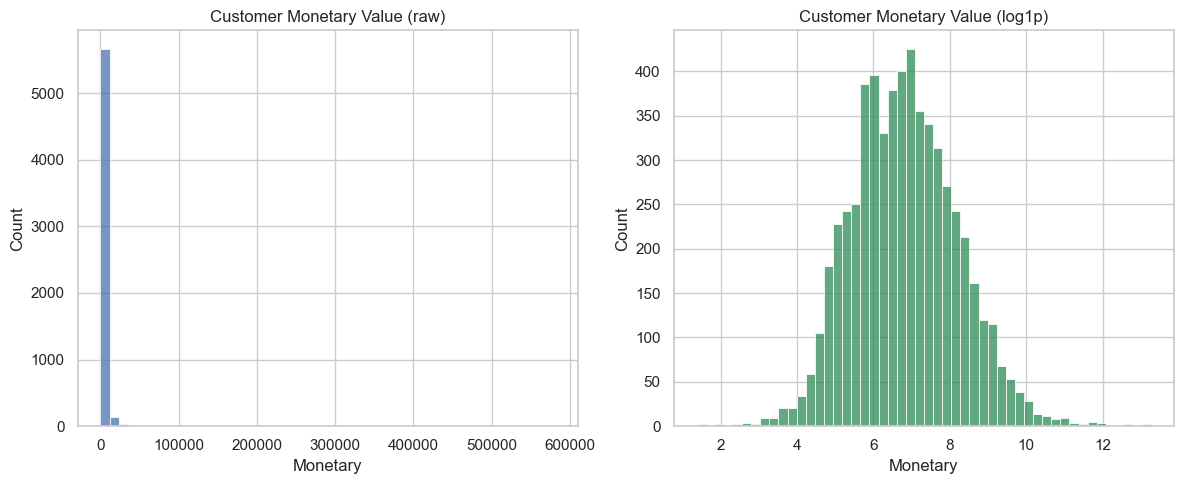

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(features["Monetary"], bins=50, ax=axes[0])
axes[0].set_title("Customer Monetary Value (raw)")
sns.histplot(np.log1p(features["Monetary"]), bins=50, ax=axes[1], color="seagreen")
axes[1].set_title("Customer Monetary Value (log1p)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_monetary_distribution_before_after.png", dpi=150)
plt.show()


In [11]:
def handle_outliers(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in ["Monetary", "Frequency", "TotalQuantity"]:
        cap = df[col].quantile(OUTLIER_UPPER_QUANTILE)
        n_capped = int((df[col] > cap).sum())
        print(f"Winsorizing {col}: capping {n_capped} customers above the {OUTLIER_UPPER_QUANTILE:.0%} quantile ({cap:,.2f})")
        df[col] = df[col].clip(upper=cap)
    return df


def transform_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in ["Monetary", "Frequency", "TotalQuantity", "UniqueProducts", "AvgOrderValue", "AvgItemsPerOrder"]:
        df[col] = np.log1p(df[col].clip(lower=0))
    # Only present for the full training table (not the single-row predict
    # input, which never carries this column) -- guard so this function
    # works for both.
    if "AvgDaysBetweenPurchases" in df.columns:
        df["AvgDaysBetweenPurchases"] = df["AvgDaysBetweenPurchases"].fillna(df["AvgDaysBetweenPurchases"].max())
    return df


outlier_handled = handle_outliers(features)
transformed = transform_features(outlier_handled)

scaler = RobustScaler()
X = scaler.fit_transform(transformed[CLUSTERING_FEATURES])
print(f"\nFinal clustering matrix shape: {X.shape}")


Winsorizing Monetary: capping 59 customers above the 99% quantile (29,205.90)
Winsorizing Frequency: capping 58 customers above the 99% quantile (46.00)
Winsorizing TotalQuantity: capping 59 customers above the 99% quantile (17,090.35)

Final clustering matrix shape: (5878, 9)


## 9. Clustering Hyperparameter Search & Algorithm Comparison


In [12]:
def safe_metrics(X, labels):
    if len(set(labels)) < 2:
        return {"silhouette": np.nan, "calinski_harabasz": np.nan, "davies_bouldin": np.nan}
    return {
        "silhouette": silhouette_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels),
    }

results = []
fitted_candidates = {}

print("Evaluating K-Means...")
for k in KMEANS_K_RANGE:
    model = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    labels = model.fit_predict(X)
    metrics = safe_metrics(X, labels)
    key = ("KMeans", f"k={k}")
    fitted_candidates[key] = (model, labels)
    results.append({"algorithm": "KMeans", "params": f"k={k}", "n_clusters": k, "inertia": model.inertia_, **metrics})

print("Evaluating Agglomerative Clustering...")
for linkage in AGG_LINKAGES:
    for k in AGG_K_RANGE:
        model = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        labels = model.fit_predict(X)
        metrics = safe_metrics(X, labels)
        key = ("Agglomerative", f"k={k}, linkage={linkage}")
        fitted_candidates[key] = (model, labels)
        results.append({"algorithm": "Agglomerative", "params": f"k={k}, linkage={linkage}", "n_clusters": k, "inertia": np.nan, **metrics})

print("Evaluating Gaussian Mixture Models...")
for cov_type in GMM_COV_TYPES:
    for n in GMM_N_RANGE:
        try:
            model = GaussianMixture(n_components=n, covariance_type=cov_type, random_state=RANDOM_SEED)
            labels = model.fit_predict(X)
        except Exception as e:
            continue
        metrics = safe_metrics(X, labels)
        key = ("GMM", f"n_components={n}, covariance={cov_type}")
        fitted_candidates[key] = (model, labels)
        results.append({"algorithm": "GMM", "params": f"n_components={n}, covariance={cov_type}", "n_clusters": n, "inertia": np.nan, **metrics})

comparison_table = pd.DataFrame(results).sort_values("silhouette", ascending=False).reset_index(drop=True)
comparison_table.to_csv(REPORTS_DIR / "model_comparison.csv", index=False)
comparison_table.head(10)


Evaluating K-Means...


  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.

Evaluating Agglomerative Clustering...
Evaluating Gaussian Mixture Models...


,algorithm,params,n_clusters,inertia,silhouette,calinski_harabasz,davies_bouldin
0,Agglomerative,"k=2, linkage=average",2,NaN,0.64,71.35,0.50
1,Agglomerative,"k=3, linkage=average",3,NaN,0.56,75.71,0.59
2,Agglomerative,"k=4, linkage=average",4,NaN,0.48,283.56,0.65
3,Agglomerative,"k=5, linkage=average",5,NaN,0.46,217.24,0.76
4,Agglomerative,"k=6, linkage=average",6,NaN,0.46,174.97,0.71
5,Agglomerative,"k=7, linkage=average",7,NaN,0.42,146.42,0.63
6,Agglomerative,"k=2, linkage=complete",2,NaN,0.36,540.45,1.12
7,KMeans,k=2,2,"15,727.28",0.33,"3,729.97",1.13
8,Agglomerative,"k=2, linkage=ward",2,NaN,0.32,"3,351.80",1.14
9,Agglomerative,"k=8, linkage=average",8,NaN,0.31,170.01,0.72


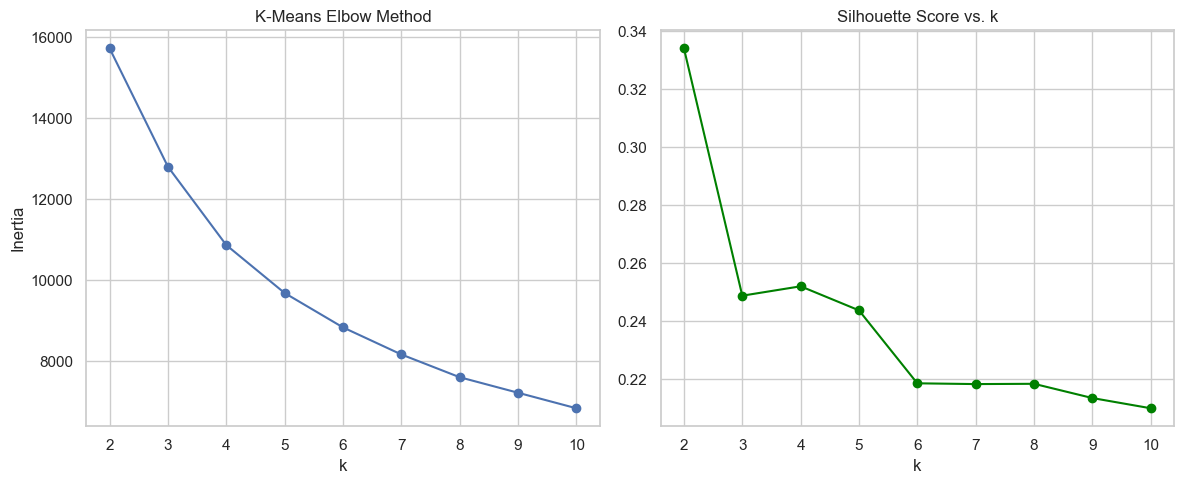

In [13]:
kmeans_only = comparison_table[comparison_table["algorithm"] == "KMeans"].sort_values("n_clusters")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(kmeans_only["n_clusters"], kmeans_only["inertia"], marker="o")
axes[0].set_title("K-Means Elbow Method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")

axes[1].plot(kmeans_only["n_clusters"], kmeans_only["silhouette"], marker="o", color="green")
axes[1].set_title("Silhouette Score vs. k"); axes[1].set_xlabel("k")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_kmeans_elbow_silhouette.png", dpi=150)
plt.show()


## 10. Best Configuration Selection & Final Model Training


In [14]:
valid_results = comparison_table.dropna(subset=["silhouette"])
best_row = valid_results.iloc[0]
best_algorithm, best_params = best_row["algorithm"], best_row["params"]

final_model, labels = fitted_candidates[(best_algorithm, best_params)]

print(f"Selected configuration: {best_algorithm} ({best_params})")
print(f"  Silhouette Score:      {best_row['silhouette']:.4f}")
print(f"  Calinski-Harabasz:     {best_row['calinski_harabasz']:.2f}")
print(f"  Davies-Bouldin:        {best_row['davies_bouldin']:.4f}")

supports_live_prediction = hasattr(final_model, "predict")
print(f"  Supports new-customer prediction: {supports_live_prediction}"
      + ("" if supports_live_prediction else " (Agglomerative Clustering has no .predict())"))


Selected configuration: Agglomerative (k=2, linkage=average)
  Silhouette Score:      0.6384
  Calinski-Harabasz:     71.35
  Davies-Bouldin:        0.5048
  Supports new-customer prediction: False (Agglomerative Clustering has no .predict())


## 11. PCA Visualization


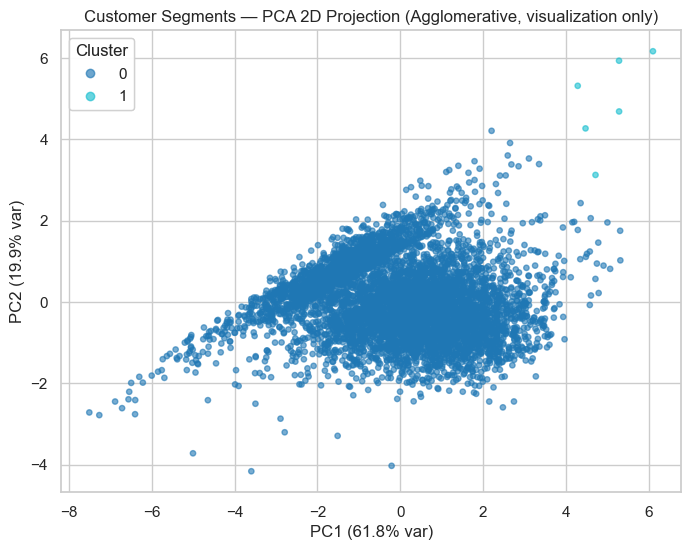

In [15]:
pca = PCA(n_components=2, random_state=RANDOM_SEED)
coords = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=labels, cmap="tab10", alpha=0.6, s=15)
ax.set_title(f"Customer Segments — PCA 2D Projection ({best_algorithm}, visualization only)")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
legend = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend)
plt.savefig(FIGURES_DIR / "05_pca_cluster_projection.png", dpi=150)
plt.show()


## 12. Dynamic Cluster Profiling & Segment Naming


In [16]:
features["Cluster"] = labels
profile_cols = ["Recency", "Frequency", "Monetary", "AvgOrderValue", "TotalQuantity", "UniqueProducts", "CustomerLifetimeDays"]

profiles = features.groupby("Cluster")[profile_cols].mean()
profiles["customer_count"] = features.groupby("Cluster").size()
profiles["pct_of_customers"] = 100 * profiles["customer_count"] / len(features)
profiles["total_revenue"] = features.groupby("Cluster")["Monetary"].sum()
profiles["pct_of_revenue"] = 100 * profiles["total_revenue"] / features["Monetary"].sum()

n_clusters_found = len(profiles)

def rank_tier(rank, n):
    if n <= 1:
        return "medium"
    position = (rank - 1) / (n - 1)
    if position <= 1/3: return "high"
    if position <= 2/3: return "medium"
    return "low"

def compose_name(m_tier, f_tier, r_tier):
    if m_tier == "high" and f_tier == "high" and r_tier in ("high", "medium"):
        return "High-Value Frequent Customers"
    if r_tier == "low" and f_tier == "low" and m_tier != "high":
        return "At-Risk / Low-Engagement Customers"
    if m_tier == "high" and f_tier != "high":
        return "High-Spending Occasional Customers"
    if f_tier == "high" and m_tier != "high":
        return "Frequent Low-Spend Customers"
    if r_tier == "high" and m_tier == "medium" and f_tier == "medium":
        return "Recently Active Growing Customers"
    if m_tier == "low" and f_tier == "low" and r_tier == "low":
        return "Dormant / Churned Customers"
    return "Moderate / Average Engagement Customers"

profiles["monetary_rank"] = profiles["Monetary"].rank(ascending=False, method="min").astype(int)
profiles["frequency_rank"] = profiles["Frequency"].rank(ascending=False, method="min").astype(int)
profiles["recency_rank"] = profiles["Recency"].rank(ascending=True, method="min").astype(int)

names = {}
for cid, row in profiles.iterrows():
    names[cid] = compose_name(
        rank_tier(row["monetary_rank"], n_clusters_found),
        rank_tier(row["frequency_rank"], n_clusters_found),
        rank_tier(row["recency_rank"], n_clusters_found),
    )

name_counts = Counter(names.values())
if any(c > 1 for c in name_counts.values()):
    seen = {}
    for cid in sorted(names, key=lambda c: profiles.loc[c, "monetary_rank"]):
        if name_counts[names[cid]] > 1:
            seen[names[cid]] = seen.get(names[cid], 0) + 1
            names[cid] = f"{names[cid]} (Tier {seen[names[cid]]})"

profiles["segment_name"] = pd.Series(names)

def business_insight(row):
    return (
        f"Segment '{row['segment_name']}' represents {row['pct_of_customers']:.1f}% of customers and "
        f"contributes {row['pct_of_revenue']:.1f}% of total revenue. On average these customers last "
        f"purchased {row['Recency']:.0f} days ago, placed {row['Frequency']:.1f} orders, and spent "
        f"{row['Monetary']:.2f} in total (avg order value {row['AvgOrderValue']:.2f}). Relative to the "
        f"other segments in this run, this group ranks #{int(row['monetary_rank'])} on revenue, "
        f"#{int(row['frequency_rank'])} on order frequency, and #{int(row['recency_rank'])} on recency (1=best)."
    )

profiles["business_insight"] = profiles.apply(business_insight, axis=1)
profiles_display = profiles.reset_index().sort_values("monetary_rank")
profiles_display.to_csv(REPORTS_DIR / "cluster_profiles.csv", index=False)
profiles_display[["Cluster", "segment_name", "customer_count", "pct_of_customers", "pct_of_revenue",
                   "Recency", "Frequency", "Monetary", "AvgOrderValue"]]


,Cluster,segment_name,customer_count,pct_of_customers,pct_of_revenue,Recency,Frequency,Monetary,AvgOrderValue
1,1,High-Spending Occasional Customers,6,0.10,2.00,366.17,4.00,"57,902.76","22,520.19"
0,0,Frequent Low-Spend Customers,5872,99.90,98.00,201.16,6.29,"2,899.76",362.56


In [17]:
for _, row in profiles_display.iterrows():
    print(f"\n--- Cluster {int(row['Cluster'])}: {row['segment_name']} ---")
    print(row["business_insight"])



--- Cluster 1: High-Spending Occasional Customers ---
Segment 'High-Spending Occasional Customers' represents 0.1% of customers and contributes 2.0% of total revenue. On average these customers last purchased 366 days ago, placed 4.0 orders, and spent 57902.76 in total (avg order value 22520.19). Relative to the other segments in this run, this group ranks #1 on revenue, #2 on order frequency, and #2 on recency (1=best).

--- Cluster 0: Frequent Low-Spend Customers ---
Segment 'Frequent Low-Spend Customers' represents 99.9% of customers and contributes 98.0% of total revenue. On average these customers last purchased 201 days ago, placed 6.3 orders, and spent 2899.76 in total (avg order value 362.56). Relative to the other segments in this run, this group ranks #2 on revenue, #1 on order frequency, and #1 on recency (1=best).


## 13. Segment Visualization

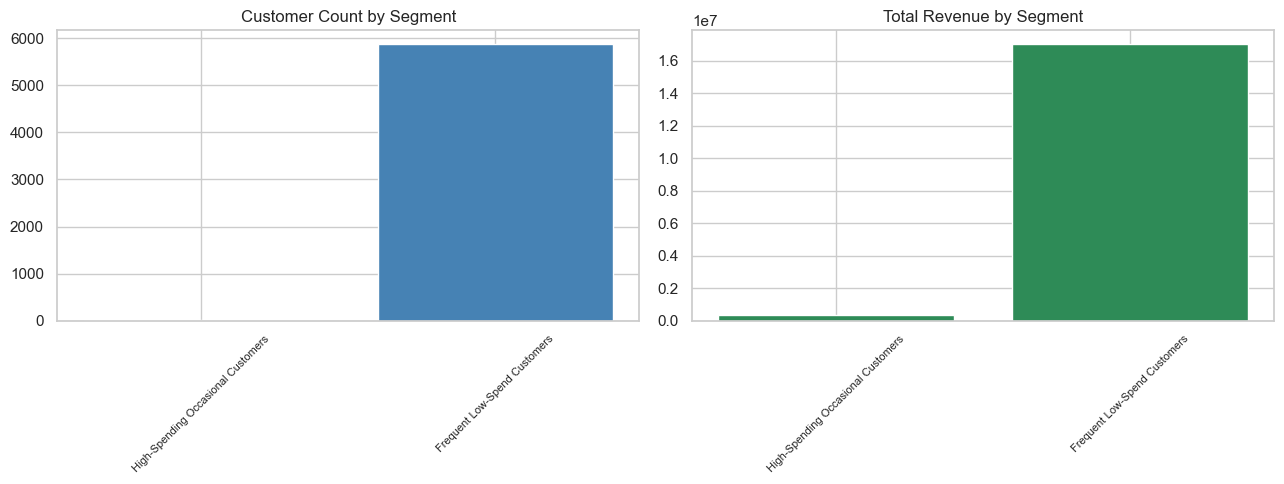

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(profiles_display["segment_name"], profiles_display["customer_count"], color="steelblue")
axes[0].set_title("Customer Count by Segment"); axes[0].tick_params(axis="x", rotation=45, labelsize=8)

axes[1].bar(profiles_display["segment_name"], profiles_display["total_revenue"], color="seagreen")
axes[1].set_title("Total Revenue by Segment"); axes[1].tick_params(axis="x", rotation=45, labelsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_segment_customers_and_revenue.png", dpi=150)
plt.show()


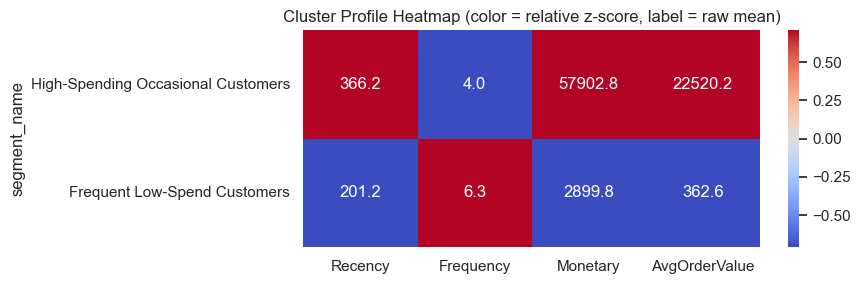

In [19]:
heat_cols = ["Recency", "Frequency", "Monetary", "AvgOrderValue"]
matrix = profiles_display.set_index("segment_name")[heat_cols]
normalized = (matrix - matrix.mean()) / matrix.std()

fig, ax = plt.subplots(figsize=(9, max(3, 0.7 * len(matrix))))
sns.heatmap(normalized, annot=matrix.round(1), fmt="", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Cluster Profile Heatmap (color = relative z-score, label = raw mean)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_cluster_profile_heatmap.png", dpi=150)
plt.show()


## 14. Save the Trained Model

Persists the fitted scaler, clustering model, and all metadata needed to
classify a new customer or reproduce this run's segment definitions later,
without retraining.


In [20]:
joblib.dump(scaler, MODELS_DIR / "preprocessing.joblib")
joblib.dump(final_model, MODELS_DIR / "clustering_model.joblib")

metadata = {
    "algorithm": best_algorithm,
    "params": best_params,
    "n_clusters": n_clusters_found,
    "silhouette_score": float(best_row["silhouette"]),
    "calinski_harabasz_score": float(best_row["calinski_harabasz"]),
    "davies_bouldin_score": float(best_row["davies_bouldin"]),
    "clustering_features": CLUSTERING_FEATURES,
    "random_seed": RANDOM_SEED,
    "n_customers_trained": len(features),
    "supports_live_prediction": supports_live_prediction,
    "cluster_profiles": profiles_display.to_dict(orient="records"),
}
joblib.dump(metadata, MODELS_DIR / "metadata.joblib")

print("Saved:")
print(f"  {MODELS_DIR / 'preprocessing.joblib'}")
print(f"  {MODELS_DIR / 'clustering_model.joblib'}")
print(f"  {MODELS_DIR / 'metadata.joblib'}")


Saved:
  models\preprocessing.joblib
  models\clustering_model.joblib
  models\metadata.joblib


## 15. Predict a New Customer's Segment


In [21]:
def predict_segment(recency, frequency, monetary, avg_order_value, total_quantity,
                     unique_products, customer_lifetime_days):
    if not metadata["supports_live_prediction"]:
        print(f"'{best_algorithm}' has no .predict() method for new points -- "
              "re-run with K-Means or GMM selected as the best configuration to enable this.")
        return None

    avg_items_per_order = total_quantity / frequency if frequency else 0.0
    purchase_frequency_rate = frequency / (customer_lifetime_days + 1)

    row = pd.DataFrame([{
        "Recency": recency, "Frequency": frequency, "Monetary": monetary,
        "AvgOrderValue": avg_order_value, "TotalQuantity": total_quantity,
        "UniqueProducts": unique_products, "AvgItemsPerOrder": avg_items_per_order,
        "CustomerLifetimeDays": customer_lifetime_days, "PurchaseFrequencyRate": purchase_frequency_rate,
    }])
    row_transformed = transform_features(row)
    X_new = scaler.transform(row_transformed[CLUSTERING_FEATURES])
    cluster_id = int(final_model.predict(X_new)[0])

    profile = next(p for p in metadata["cluster_profiles"] if int(p["Cluster"]) == cluster_id)
    print(f"Predicted segment: {profile['segment_name']} (cluster {cluster_id})")
    print(profile["business_insight"])
    return profile


# Example (edit these values to try your own customer):
_ = predict_segment(
    recency=15, frequency=8, monetary=950.0, avg_order_value=118.75,
    total_quantity=64, unique_products=18, customer_lifetime_days=220,
)


'Agglomerative' has no .predict() method for new points -- re-run with K-Means or GMM selected as the best configuration to enable this.


## 16. Final Output


In [22]:
print("=" * 70)
print("BEHAVIORAL CUSTOMER SEGMENTATION — FINAL SUMMARY")
print("=" * 70)
print(f"Customers analyzed:        {len(features):,}")
print(f"Date range:                {clean_df['InvoiceDate'].min().date()} to {clean_df['InvoiceDate'].max().date()}")
print(f"Algorithm selected:       {best_algorithm} ({best_params})")
print(f"Segments discovered:       {n_clusters_found}")
print(f"Silhouette / CH / DB:      {best_row['silhouette']:.4f} / {best_row['calinski_harabasz']:.2f} / {best_row['davies_bouldin']:.4f}")
print(f"Live prediction supported: {supports_live_prediction}")
print("-" * 70)
for _, row in profiles_display.iterrows():
    print(f"  Cluster {int(row['Cluster'])}: {row['segment_name']:<40s} "
          f"{row['pct_of_customers']:5.1f}% of customers, {row['pct_of_revenue']:5.1f}% of revenue")
print("=" * 70)
print(f"\nReports saved to: {REPORTS_DIR.resolve()}")
print(f"Model artifacts saved to: {MODELS_DIR.resolve()}")


BEHAVIORAL CUSTOMER SEGMENTATION — FINAL SUMMARY
Customers analyzed:        5,878
Date range:                2009-12-01 to 2011-12-09
Algorithm selected:       Agglomerative (k=2, linkage=average)
Segments discovered:       2
Silhouette / CH / DB:      0.6384 / 71.35 / 0.5048
Live prediction supported: False
----------------------------------------------------------------------
  Cluster 1: High-Spending Occasional Customers         0.1% of customers,   2.0% of revenue
  Cluster 0: Frequent Low-Spend Customers              99.9% of customers,  98.0% of revenue

Reports saved to: C:\PROJECTS\RESUME_Projects\behavioral_customer_segmentation\reports
Model artifacts saved to: C:\PROJECTS\RESUME_Projects\behavioral_customer_segmentation\models
